In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.svm import SVR
# from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [3]:
air_quality = fetch_ucirepo(id=477)
# https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set

X = air_quality.data.features 
y = air_quality.data.targets

In [4]:
df_x = X[[
    'X1 transaction date',
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
]].copy()

df_x.rename(
    columns={
        'X1 transaction date': 'transaction_date',
        'X2 house age': 'house_age',
        'X3 distance to the nearest MRT station': 'nearest_station_distance',
        'X4 number of convenience stores': 'near_stores_number',
    },
    inplace=True
)

df_y = y.copy()

In [6]:
df_x

,transaction_date,house_age,nearest_station_distance,near_stores_number
0,2012.917,32.0,84.87882,10
1,2012.917,19.5,306.59470,9
2,2013.583,13.3,561.98450,5
3,2013.500,13.3,561.98450,5
4,2012.833,5.0,390.56840,5
...,...,...,...,...
409,2013.000,13.7,4082.01500,0
410,2012.667,5.6,90.45606,9
411,2013.250,18.8,390.96960,7
412,2013.000,8.1,104.81010,5


In [5]:
df_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_date          414 non-null    float64
 1   house_age                 414 non-null    float64
 2   nearest_station_distance  414 non-null    float64
 3   near_stores_number        414 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 13.1 KB


In [7]:
df_x.describe(include='all')

,transaction_date,house_age,nearest_station_distance,near_stores_number
count,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203
std,0.281967,11.392485,1262.109595,2.945562
min,2012.667000,0.000000,23.382840,0.000000
25%,2012.917000,9.025000,289.324800,1.000000
50%,2013.167000,16.100000,492.231300,4.000000
75%,2013.417000,28.150000,1454.279000,6.000000
max,2013.583000,43.800000,6488.021000,10.000000


In [5]:
df_x.corr()

,transaction_date,house_age,nearest_station_distance,near_stores_number
transaction_date,1.000000,0.017549,0.060880,0.009635
house_age,0.017549,1.000000,0.025622,0.049593
nearest_station_distance,0.060880,0.025622,1.000000,-0.602519
near_stores_number,0.009635,0.049593,-0.602519,1.000000


array([[<Axes: xlabel='transaction_date', ylabel='transaction_date'>,
        <Axes: xlabel='house_age', ylabel='transaction_date'>,
        <Axes: xlabel='nearest_station_distance', ylabel='transaction_date'>,
        <Axes: xlabel='near_stores_number', ylabel='transaction_date'>],
       [<Axes: xlabel='transaction_date', ylabel='house_age'>,
        <Axes: xlabel='house_age', ylabel='house_age'>,
        <Axes: xlabel='nearest_station_distance', ylabel='house_age'>,
        <Axes: xlabel='near_stores_number', ylabel='house_age'>],
       [<Axes: xlabel='transaction_date', ylabel='nearest_station_distance'>,
        <Axes: xlabel='house_age', ylabel='nearest_station_distance'>,
        <Axes: xlabel='nearest_station_distance', ylabel='nearest_station_distance'>,
        <Axes: xlabel='near_stores_number', ylabel='nearest_station_distance'>],
       [<Axes: xlabel='transaction_date', ylabel='near_stores_number'>,
        <Axes: xlabel='house_age', ylabel='near_stores_number'>,
       

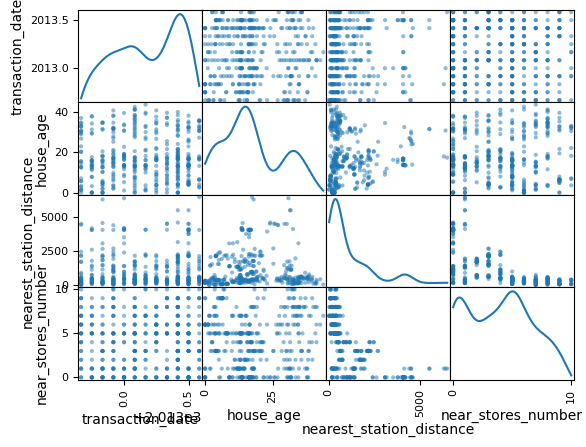

In [44]:
pd.plotting.scatter_matrix(df_x, diagonal='kde')

In [36]:
model_reg_lin = LinearRegression()

model_reg_lin.fit(
    X=df_x.to_numpy(),
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_lin.predict(df_x.to_numpy())
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.5552973207362726

In [118]:
model_reg_lin = LinearRegression()

poly_features_ins = PolynomialFeatures(degree=5, include_bias=False)
poly_features_fit = poly_features_ins.fit_transform(df_x.to_numpy())

model_reg_lin.fit(
    X=poly_features_fit,
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_lin.predict(poly_features_fit)
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.7291852262246907

In [68]:
model_reg_ridge = Ridge(alpha=10)

model_reg_ridge.fit(
    X=df_x.to_numpy(),
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_ridge.predict(df_x.to_numpy())
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.5545143467348619

In [79]:
model_reg_ridge = Lasso(alpha=0.01)

model_reg_ridge.fit(
    X=df_x.to_numpy(),
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_ridge.predict(df_x.to_numpy())
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.5552904287923137

In [97]:
model_reg_ridge = Lasso(alpha=100, tol=1e+3)

poly_features_ins = PolynomialFeatures(degree=10, include_bias=False)
poly_features_fit = poly_features_ins.fit_transform(df_x.to_numpy())

model_reg_ridge.fit(
    X=poly_features_fit,
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_ridge.predict(poly_features_fit)
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.6485329606263179

In [110]:
model_reg_elastic = ElasticNet(
    alpha=10,
    l1_ratio=0.5,
    tol=1e+2
)

poly_features_ins = PolynomialFeatures(degree=10, include_bias=False)
poly_features_fit = poly_features_ins.fit_transform(df_x.to_numpy())

model_reg_elastic.fit(
    X=poly_features_fit,
    y=df_y.to_numpy().ravel()
)

y_pred = model_reg_elastic.predict(poly_features_fit)
r2 = r2_score(y_true=df_y.to_numpy().ravel(), y_pred=y_pred)
r2

0.6476363838412196